In [1]:
# Importation des module Python nécéssaires

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1 - Organisation des données 


### 1-1 Fusion des données 

On va fusionner les données électorales avec les donnée quantitatives

In [2]:
#Importation des données  des résultats des corrélations de votes

politiques = pd.read_csv("correlation_politique.csv",sep=',',encoding="ISO-8859-1")

politiques = politiques.set_index('id_bv',drop=True)

politiques.head(5)

,taux_ab,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,...,v_D_EUR,p_D_EUR,v_D_LEG,p_D_LEG,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite
id_bv,,,,,,,,,,,,,,,,,,,,,
01_01,0.276852,295,282,-13,0.4617,0.3648,136,66,4,84,...,188,0.2942,166,0.2147,-22,72,60,42,2,12
01_02,0.253509,329,312,-17,0.4796,0.3486,171,72,5,71,...,154,0.2245,164,0.1832,10,54,54,37,2,7
01_03,0.278282,369,323,-46,0.4933,0.3730,178,86,11,86,...,183,0.2447,195,0.2252,12,58,71,37,0,17
01_04,0.295753,390,434,44,0.5328,0.4822,175,66,15,125,...,175,0.2391,151,0.1678,-24,51,69,34,1,20
01_05,0.235840,338,321,-17,0.5248,0.3924,173,79,5,75,...,153,0.2376,138,0.1687,-15,44,53,41,3,12


In [3]:
# Importation des données quantitaitives 

quant = pd.read_csv("Données quantitatives.csv",sep=",",encoding="ISO-8859-1")

quant = quant.set_index('id_bv',drop=True)

quant.head(5)

,taux_ab,p_procuration,nombre_jeune,p_etranger,nb_nature,age_moyen,revenu_annuel,prix_immo_m2,pour_logSocial,pourct_T1/T2
id_bv,,,,,,,,,,
01_01,0.276852,0.119444,17,0.166667,1.0,49.7,56,12.7,0.01,0.20
01_02,0.253509,0.113130,7,0.170107,4.0,47.6,54,13.0,0.05,0.65
01_03,0.278282,0.115607,6,0.164327,0.0,48.7,36,10.0,0.05,0.80
01_04,0.295753,0.102703,13,0.183012,6.0,49.0,33,10.3,0.05,0.80
01_05,0.235840,0.134633,13,0.155989,2.0,47.0,37,9.5,0.30,0.80


In [4]:
#Fusion des deux données 

quant_pol = politiques.merge(quant,on='id_bv')

quant_pol = quant_pol.rename(columns = {"taux_ab_x":'taux_abstention'})

quant_pol = quant_pol.drop("taux_ab_y",axis=1)

                                        
quant_pol.head(10)

,taux_abstention,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,...,nb_extDroite,p_procuration,nombre_jeune,p_etranger,nb_nature,age_moyen,revenu_annuel,prix_immo_m2,pour_logSocial,pourct_T1/T2
id_bv,,,,,,,,,,,,,,,,,,,,,
01_01,0.276852,295,282,-13,0.4617,0.3648,136,66,4,84,...,12,0.119444,17,0.166667,1.0,49.7,56,12.7,0.01,0.20
01_02,0.253509,329,312,-17,0.4796,0.3486,171,72,5,71,...,7,0.113130,7,0.170107,4.0,47.6,54,13.0,0.05,0.65
01_03,0.278282,369,323,-46,0.4933,0.3730,178,86,11,86,...,17,0.115607,6,0.164327,0.0,48.7,36,10.0,0.05,0.80
01_04,0.295753,390,434,44,0.5328,0.4822,175,66,15,125,...,20,0.102703,13,0.183012,6.0,49.0,33,10.3,0.05,0.80
01_05,0.235840,338,321,-17,0.5248,0.3924,173,79,5,75,...,12,0.134633,13,0.155989,2.0,47.0,37,9.5,0.30,0.80
01_06,0.272297,379,339,-40,0.4834,0.3742,189,88,8,87,...,9,0.116022,22,0.184688,6.0,48.0,38,11.0,0.05,0.65
01_07,0.258792,303,259,-44,0.4202,0.3213,156,60,8,70,...,15,0.118124,9,0.168620,0.0,50.6,43,14.0,0.05,0.65
01_08,0.292909,181,173,-8,0.3261,0.2574,96,47,3,34,...,9,0.099692,11,0.197328,4.0,48.8,44,13.0,0.05,0.65
01_09,0.280514,166,148,-18,0.2862,0.2229,91,28,2,43,...,7,0.105996,11,0.149893,0.0,51.5,50,12.5,0.05,0.65


In [5]:
#Liste de colonnes

quant_pol.columns 

Index(['taux_abstention', 'total_G_EUR', 'total_G_LEG', 'ecart_voix_G',
       'p_G_EUR', 'p_G_LEG', 'nb_PS', 'nb_EELV', 'nb_PCF', 'nb_LFI',
       'autresGauche', 'ExtGauche', 'v_D_EUR', ' p_D_EUR ', 'v_D_LEG',
       ' p_D_LEG', 'ecart_D', 'nb_LR', 'nb_RN', 'nb_Rec', 'nb_autreDroite',
       'nb_extDroite', 'p_procuration', 'nombre_jeune', 'p_etranger',
       'nb_nature', 'age_moyen', 'revenu_annuel', 'prix_immo_m2',
       'pour_logSocial', 'pourct_T1/T2'],
      dtype='object')

In [6]:
#Suppression des colonnes inutiles

quant_cor = quant_pol.drop(['total_G_EUR','total_G_LEG','p_G_EUR',' p_D_EUR ','v_D_EUR','v_D_LEG'],axis=1)




quant_cor.head(5)

,taux_abstention,ecart_voix_G,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,p_D_LEG,...,nb_extDroite,p_procuration,nombre_jeune,p_etranger,nb_nature,age_moyen,revenu_annuel,prix_immo_m2,pour_logSocial,pourct_T1/T2
id_bv,,,,,,,,,,,,,,,,,,,,,
01_01,0.276852,-13,0.3648,136,66,4,84,3,2,0.2147,...,12,0.119444,17,0.166667,1.0,49.7,56,12.7,0.01,0.20
01_02,0.253509,-17,0.3486,171,72,5,71,9,1,0.1832,...,7,0.113130,7,0.170107,4.0,47.6,54,13.0,0.05,0.65
01_03,0.278282,-46,0.3730,178,86,11,86,5,3,0.2252,...,17,0.115607,6,0.164327,0.0,48.7,36,10.0,0.05,0.80
01_04,0.295753,44,0.4822,175,66,15,125,5,4,0.1678,...,20,0.102703,13,0.183012,6.0,49.0,33,10.3,0.05,0.80
01_05,0.235840,-17,0.3924,173,79,5,75,5,1,0.1687,...,12,0.134633,13,0.155989,2.0,47.0,37,9.5,0.30,0.80


In [7]:
#Suppression de l'index

quant_corr = quant_cor.reset_index()

quant_corr = quant_corr.drop("id_bv",axis=1)

quant_corr.head(5)

,taux_abstention,ecart_voix_G,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,p_D_LEG,...,nb_extDroite,p_procuration,nombre_jeune,p_etranger,nb_nature,age_moyen,revenu_annuel,prix_immo_m2,pour_logSocial,pourct_T1/T2
0,0.276852,-13,0.3648,136,66,4,84,3,2,0.2147,...,12,0.119444,17,0.166667,1.0,49.7,56,12.7,0.01,0.20
1,0.253509,-17,0.3486,171,72,5,71,9,1,0.1832,...,7,0.113130,7,0.170107,4.0,47.6,54,13.0,0.05,0.65
2,0.278282,-46,0.3730,178,86,11,86,5,3,0.2252,...,17,0.115607,6,0.164327,0.0,48.7,36,10.0,0.05,0.80
3,0.295753,44,0.4822,175,66,15,125,5,4,0.1678,...,20,0.102703,13,0.183012,6.0,49.0,33,10.3,0.05,0.80
4,0.235840,-17,0.3924,173,79,5,75,5,1,0.1687,...,12,0.134633,13,0.155989,2.0,47.0,37,9.5,0.30,0.80


### 1-2 Matrice de corrélation

On doit établir une matrice de corrélation 

In [8]:
#Matrice de corrélation

quant3 = quant_corr.corr()

quant3

,taux_abstention,ecart_voix_G,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,p_D_LEG,...,nb_extDroite,p_procuration,nombre_jeune,p_etranger,nb_nature,age_moyen,revenu_annuel,prix_immo_m2,pour_logSocial,pourct_T1/T2
taux_abstention,1.000000,0.683494,0.294746,-0.594286,-0.416568,0.048824,0.424015,-0.147885,0.214411,0.093863,...,0.178115,-0.799371,0.352458,0.841739,0.129724,-0.070155,-0.371776,-0.377866,0.633879,-0.210314
ecart_voix_G,0.683494,1.000000,0.768027,-0.132198,0.086570,0.431196,0.803101,0.075043,0.496402,-0.410204,...,0.257661,-0.665931,0.327909,0.640700,0.122347,-0.341795,-0.667749,-0.651113,0.674861,-0.017986
p_G_LEG,0.294746,0.768027,1.000000,0.433811,0.600589,0.687376,0.893819,0.313145,0.615203,-0.827201,...,0.153079,-0.338556,0.061324,0.256174,0.059130,-0.479155,-0.807978,-0.761529,0.486786,0.221713
nb_PS,-0.594286,-0.132198,0.433811,1.000000,0.877988,0.482998,0.268785,0.413495,0.248608,-0.683922,...,-0.002338,0.465704,-0.289547,-0.558270,-0.011043,-0.277248,-0.291956,-0.210342,-0.246920,0.417972
nb_EELV,-0.416568,0.086570,0.600589,0.877988,1.000000,0.562158,0.498724,0.411076,0.370086,-0.739777,...,-0.016377,0.341190,-0.217616,-0.411152,0.033745,-0.455138,-0.417063,-0.379396,-0.146763,0.431365
nb_PCF,0.048824,0.431196,0.687376,0.482998,0.562158,1.000000,0.635014,0.344718,0.472113,-0.575155,...,0.188101,-0.167104,0.023547,0.052261,0.077790,-0.207651,-0.549366,-0.527477,0.293316,0.175934
nb_LFI,0.424015,0.803101,0.893819,0.268785,0.498724,0.635014,1.000000,0.293504,0.620778,-0.630266,...,0.233959,-0.439175,0.269234,0.413742,0.137946,-0.503762,-0.743340,-0.750082,0.525439,0.169109
autresGauche,-0.147885,0.075043,0.313145,0.413495,0.411076,0.344718,0.293504,1.000000,0.257736,-0.337405,...,0.124951,0.048920,-0.044979,-0.132190,0.053040,-0.168364,-0.257247,-0.253196,0.028014,0.163219
ExtGauche,0.214411,0.496402,0.615203,0.248608,0.370086,0.472113,0.620778,0.257736,1.000000,-0.447879,...,0.182047,-0.280066,0.104209,0.208247,0.039248,-0.247855,-0.505368,-0.506063,0.335367,0.128991
p_D_LEG,0.093863,-0.410204,-0.827201,-0.683922,-0.739777,-0.575155,-0.630266,-0.337405,-0.447879,1.000000,...,0.003042,-0.064356,0.197006,0.108396,0.016830,0.460453,0.607930,0.513549,-0.175707,-0.367398


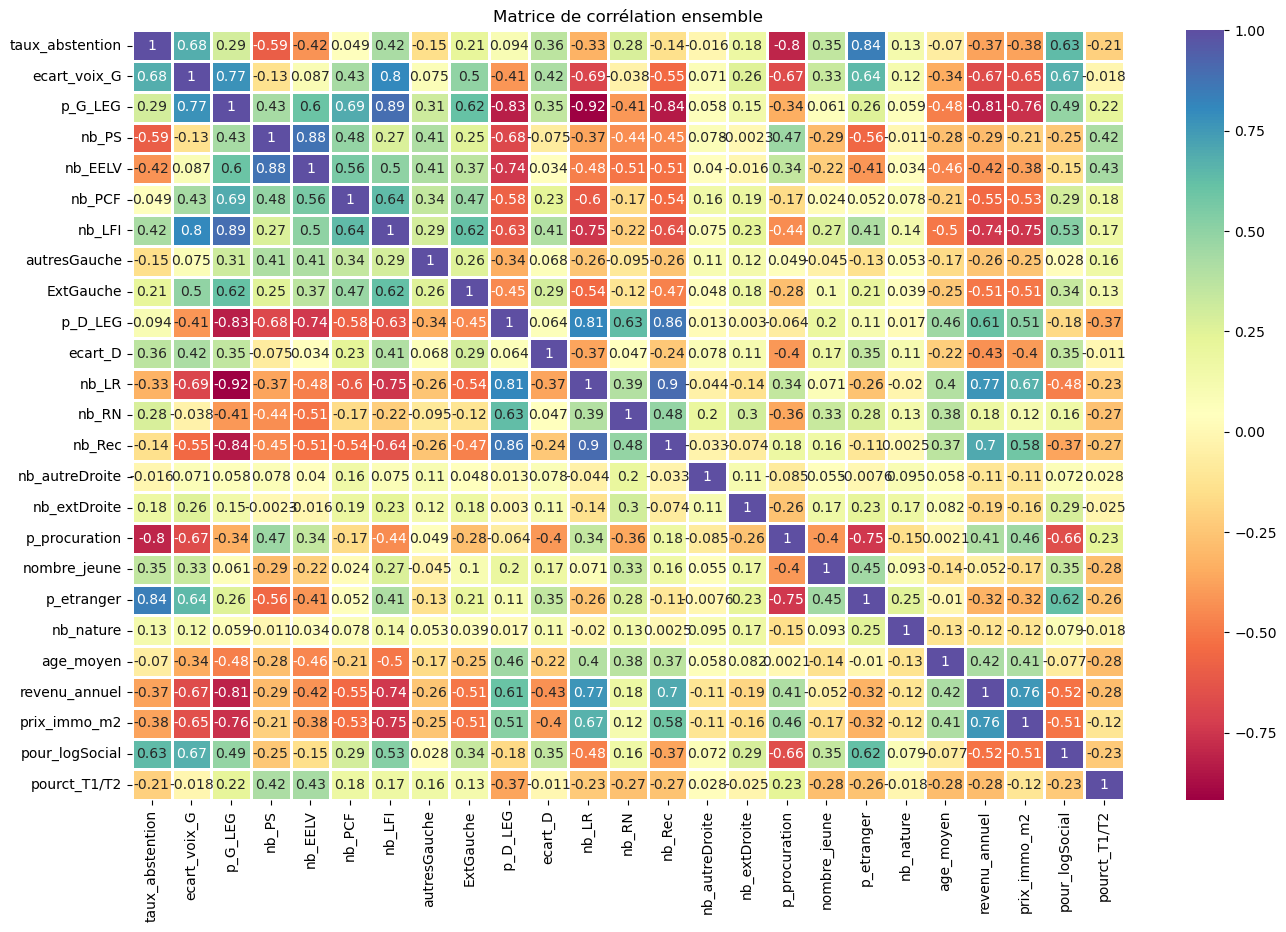

In [9]:
# Affichage de la matrice de façon graphique avec Seaborn 

plt.figure(figsize=(16,10))

sns.heatmap(quant3,cmap="Spectral",annot=True,linewidth=0.9)
plt.title("Matrice de corrélation ensemble")

plt.show()

On a la matrice de corrélation et on va l'utiliser pour en faire une réduction de dimension d'information avec les procédures d'ACP

# 2 - Réduction d'information avec l'ACP


Le but de la procédure de l'ACP est de créer de nouvelles variables 

In [10]:
#Copiage des données de départ pour l'ACP


abst_acp = quant_cor

abst_acp.head(5)

,taux_abstention,ecart_voix_G,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,p_D_LEG,...,nb_extDroite,p_procuration,nombre_jeune,p_etranger,nb_nature,age_moyen,revenu_annuel,prix_immo_m2,pour_logSocial,pourct_T1/T2
id_bv,,,,,,,,,,,,,,,,,,,,,
01_01,0.276852,-13,0.3648,136,66,4,84,3,2,0.2147,...,12,0.119444,17,0.166667,1.0,49.7,56,12.7,0.01,0.20
01_02,0.253509,-17,0.3486,171,72,5,71,9,1,0.1832,...,7,0.113130,7,0.170107,4.0,47.6,54,13.0,0.05,0.65
01_03,0.278282,-46,0.3730,178,86,11,86,5,3,0.2252,...,17,0.115607,6,0.164327,0.0,48.7,36,10.0,0.05,0.80
01_04,0.295753,44,0.4822,175,66,15,125,5,4,0.1678,...,20,0.102703,13,0.183012,6.0,49.0,33,10.3,0.05,0.80
01_05,0.235840,-17,0.3924,173,79,5,75,5,1,0.1687,...,12,0.134633,13,0.155989,2.0,47.0,37,9.5,0.30,0.80


### 2-1 Décomposition des données

On sépare (ou décompose) les données en 3 parties

    On récupères les valeurs pour chaque ligne
    On récupère tous les valeurs des bureaux de vote 
    On récupère tous les colonnes du jeux de données

In [11]:
#on récupère tous les valeurs pour chaque ligne
X = abst_acp.values

X

array([[ 2.76851852e-01, -1.30000000e+01,  3.64800000e-01, ...,
         1.27000000e+01,  1.00000000e-02,  2.00000000e-01],
       [ 2.53509496e-01, -1.70000000e+01,  3.48600000e-01, ...,
         1.30000000e+01,  5.00000000e-02,  6.50000000e-01],
       [ 2.78282411e-01, -4.60000000e+01,  3.73000000e-01, ...,
         1.00000000e+01,  5.00000000e-02,  8.00000000e-01],
       ...,
       [ 2.34659091e-01,  7.70000000e+01,  7.52300000e-01, ...,
         5.00000000e+00,  3.00000000e-01,  7.00000000e-01],
       [ 3.49785408e-01,  2.12000000e+02,  7.63600000e-01, ...,
         4.20000000e+00,  2.50000000e-01,  6.70000000e-01],
       [ 3.23098725e-01,  2.02000000e+02,  7.73700000e-01, ...,
         3.90000000e+00,  2.50000000e-01,  8.00000000e-01]])

In [12]:
#On récupère tous les numéros des bureaux de votes 
names = abst_acp.index

names

Index(['01_01', '01_02', '01_03', '01_04', '01_05', '01_06', '01_07', '01_08',
       '01_09', '01_10',
       ...
       '20_67', '20_68', '20_69', '20_70', '20_71', '20_72', '20_73', '20_74',
       '20_75', '20_76'],
      dtype='object', name='id_bv', length=901)

In [13]:
# On récupère les colonnes dont on a besoin pour les utiliséq
features = abst_acp.columns

features

Index(['taux_abstention', 'ecart_voix_G', 'p_G_LEG', 'nb_PS', 'nb_EELV',
       'nb_PCF', 'nb_LFI', 'autresGauche', 'ExtGauche', ' p_D_LEG', 'ecart_D',
       'nb_LR', 'nb_RN', 'nb_Rec', 'nb_autreDroite', 'nb_extDroite',
       'p_procuration', 'nombre_jeune', 'p_etranger', 'nb_nature', 'age_moyen',
       'revenu_annuel', 'prix_immo_m2', 'pour_logSocial', 'pourct_T1/T2'],
      dtype='object')

On va importer les modules pour traiter avec l'ACP

In [14]:
# Importation des modules ACP par Scikit-Learn

from sklearn import decomposition
from sklearn import preprocessing


### 2-2 Matrice centrée-réduite


La matrice des données centrées réduites  est la matrice obtenue à partir d’un tableau de données après deux opérations essentielles pour chaque variable (chaque colonne) :

    - Centrage : on soustrait à chaque valeur la moyenne de sa variable.
    - Réduction (standardisation) : on divise chaque valeur centrée par l’écart-type de sa variable.

Elle met toutes les variables sur la même échelle (moyenne 0 et variance 1).



In [15]:
#Centrage et Réduction des données
sc=preprocessing.StandardScaler()

std_scale = sc.fit(X)
X_scaled = std_scale.transform(X)



pd.DataFrame(X_scaled)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0.195436,-0.649403,-0.561356,-0.894343,-0.666569,-1.264367,-0.847682,-0.789591,-0.635251,0.081517,...,-0.124474,0.598709,-0.427339,-0.430138,-1.058792,0.607883,1.969380,1.498853,-0.800720,-1.852520
1,-0.258364,-0.708604,-0.655419,-0.450919,-0.536494,-1.116419,-1.011179,0.651506,-0.945642,-0.254784,...,-1.127615,0.392918,-1.734749,-0.353790,0.138161,-0.287962,1.770689,1.604344,-0.629242,0.682767
2,0.223247,-1.137810,-0.513744,-0.362234,-0.232985,-0.228735,-0.822528,-0.309225,-0.324860,0.193618,...,0.878666,0.473650,-1.865490,-0.482054,-1.457776,0.181290,-0.017532,0.549430,-0.629242,1.527863
3,0.562892,0.194210,0.120312,-0.400242,-0.666569,0.363054,-0.332035,-0.309225,-0.014469,-0.419197,...,1.480551,0.053117,-0.950303,-0.067451,0.936129,0.309268,-0.315568,0.654921,-0.629242,1.527863
4,-0.601872,-0.708604,-0.401100,-0.425580,-0.384739,-1.116419,-0.960872,-0.309225,-0.945642,-0.409589,...,-0.124474,1.093692,-0.950303,-0.667073,-0.659807,-0.543918,0.081814,0.373611,0.442492,1.527863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
896,0.558610,2.073837,1.719967,-0.134187,0.785937,1.250738,2.849884,0.171140,1.847877,-1.160127,...,0.276782,0.364466,0.226366,0.421351,-1.058792,-0.799874,-1.010987,-1.173597,1.514226,0.119370
897,-0.576419,0.667817,1.532421,1.272100,2.130046,0.806896,2.158163,-0.309225,2.158268,-1.349096,...,1.681179,0.399048,0.749330,-0.343730,-0.659807,-0.885193,-0.911642,-0.997778,-0.200549,0.682767
898,-0.624836,0.682617,1.688612,1.398793,2.173404,2.286369,2.673809,0.171140,-0.324860,-1.418491,...,1.681179,1.020470,-0.950303,-0.383909,-1.058792,-0.458599,-1.010987,-1.208761,0.442492,0.964466
899,1.613342,2.680646,1.754224,-0.818327,0.439070,1.250738,2.950498,0.171140,2.779050,-1.166533,...,0.678038,-1.545510,-0.035116,1.502321,-0.659807,-1.226467,-1.110333,-1.490072,0.228145,0.795447


In [16]:
abst_acp.columns

Index(['taux_abstention', 'ecart_voix_G', 'p_G_LEG', 'nb_PS', 'nb_EELV',
       'nb_PCF', 'nb_LFI', 'autresGauche', 'ExtGauche', ' p_D_LEG', 'ecart_D',
       'nb_LR', 'nb_RN', 'nb_Rec', 'nb_autreDroite', 'nb_extDroite',
       'p_procuration', 'nombre_jeune', 'p_etranger', 'nb_nature', 'age_moyen',
       'revenu_annuel', 'prix_immo_m2', 'pour_logSocial', 'pourct_T1/T2'],
      dtype='object')

In [26]:
X_scaled_abst = pd.DataFrame(X_scaled)

#Renommage des colonnes
X_scaled_abst = X_scaled_abst.rename(columns = {0:'taux_abstention',
                             1:'ecart_voix_G',
                             2:'p_G_LEG',
                             3:'nb_PS',
                             4:'nb_EELV',
                             5:'nb_PCF',
                             6: 'nb_LFI',
                             7:'autresGauche',
                             8:'ExtGauche',
                             9:'p_D_LEG',
                             10:'ecart_D',
                             11:'nb_LR',
                             12:'nb_RN',
                             13:'nb_Rec',
                             14:'nb_autreDroite',
                             15:'nb_extDroite',
                             16:'p_procuration',
                             17:'nombre_jeune',
                             18:"p_etranger",
                             19:"nb_nature",
                             20:"age_moyen",
                             21:"revenu_annuel",
                             22:"prix_immo_m2",
                             23:"pourct_T1/T2",
                             24:"pour_logSocial"})

X_scaled_abst.to_csv('tableau_centre-reduite.csv',header = True)


#Matrice centré-réduite
X_scaled_abst.head(5)

,taux_abstention,ecart_voix_G,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,p_D_LEG,...,nb_extDroite,p_procuration,nombre_jeune,p_etranger,nb_nature,age_moyen,revenu_annuel,prix_immo_m2,pourct_T1/T2,pour_logSocial
0,0.195436,-0.649403,-0.561356,-0.894343,-0.666569,-1.264367,-0.847682,-0.789591,-0.635251,0.081517,...,-0.124474,0.598709,-0.427339,-0.430138,-1.058792,0.607883,1.969380,1.498853,-0.800720,-1.852520
1,-0.258364,-0.708604,-0.655419,-0.450919,-0.536494,-1.116419,-1.011179,0.651506,-0.945642,-0.254784,...,-1.127615,0.392918,-1.734749,-0.353790,0.138161,-0.287962,1.770689,1.604344,-0.629242,0.682767
2,0.223247,-1.137810,-0.513744,-0.362234,-0.232985,-0.228735,-0.822528,-0.309225,-0.324860,0.193618,...,0.878666,0.473650,-1.865490,-0.482054,-1.457776,0.181290,-0.017532,0.549430,-0.629242,1.527863
3,0.562892,0.194210,0.120312,-0.400242,-0.666569,0.363054,-0.332035,-0.309225,-0.014469,-0.419197,...,1.480551,0.053117,-0.950303,-0.067451,0.936129,0.309268,-0.315568,0.654921,-0.629242,1.527863
4,-0.601872,-0.708604,-0.401100,-0.425580,-0.384739,-1.116419,-0.960872,-0.309225,-0.945642,-0.409589,...,-0.124474,1.093692,-0.950303,-0.667073,-0.659807,-0.543918,0.081814,0.373611,0.442492,1.527863


### 3-2 Valeurs propres



In [27]:
#Déterminantion de l'inertie de l'information 

pca_train = decomposition.PCA(n_components=20)
pca_train.fit(X_scaled)


print(pca_train)

PCA(n_components=20)


On aura 20 valeurs propres à étudier 

On va détermier la part d'information prise par le modèle (la part de la variance expliqué)

In [28]:
#Les part de variance expliqué par composante principale
print(pca_train.explained_variance_ratio_)

[0.35471002 0.21274792 0.06477717 0.04692005 0.03963088 0.03750526
 0.03377155 0.03145355 0.0276703  0.02443276 0.02149589 0.01803485
 0.01532023 0.01252302 0.01205616 0.00962024 0.00827506 0.00758943
 0.00707276 0.00475715]


In [29]:
#Les part de variance cumulés expliqué 
print(pca_train.explained_variance_ratio_.cumsum())

[0.35471002 0.56745794 0.63223511 0.67915516 0.71878604 0.7562913
 0.79006285 0.8215164  0.8491867  0.87361946 0.89511535 0.9131502
 0.92847044 0.94099346 0.95304962 0.96266986 0.97094492 0.97853435
 0.98560711 0.99036426]


In [30]:
#Notre valeur propore cumulé

val_propre = pca_train.explained_variance_ratio_.cumsum()

In [31]:
#Valeur de l'inertie
val_propre = pd.DataFrame(pca_train.explained_variance_ratio_)
val_propre = val_propre.rename(columns = {0:'val_propre'})

#valeur de l'innertie en cumulé
val_propre2 = pd.DataFrame(pca_train.explained_variance_ratio_.cumsum())
val_propre2 = val_propre2.rename(columns = {0:'val_propre cumulé'})


#Rassembler les deux colonnes
val_propre3 = pd.concat([val_propre,val_propre2],axis=1)


#val_propre3 = val_propre3.rename(columns = {0:'val_propre',0:'val_propre cumulé'})

val_propre3

,val_propre,val_propre cumulé
0,0.354710,0.354710
1,0.212748,0.567458
2,0.064777,0.632235
3,0.046920,0.679155
4,0.039631,0.718786
5,0.037505,0.756291
6,0.033772,0.790063
7,0.031454,0.821516
8,0.027670,0.849187
9,0.024433,0.873619


On a 56,7 % de la part de la variance prise par le modeèle

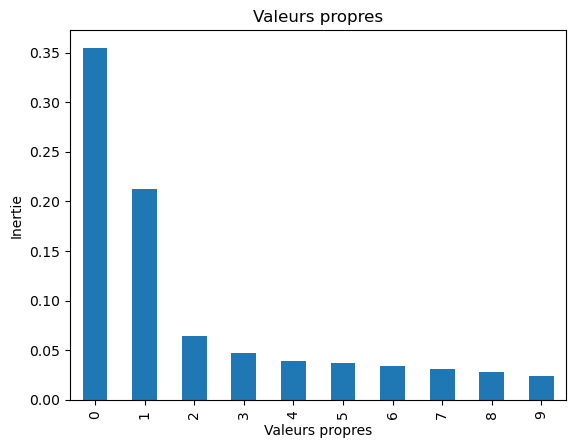

In [33]:
val_propre3.head(10)['val_propre'].plot(kind='bar')

plt.xlabel("Valeurs propres")
plt.ylabel("Inertie")
plt.title("Valeurs propres")

plt.savefig("Valeurs propres.png")
plt.show() 

On va récupérer 59,6% de l'inertie de l'information

### 3-3 Vecteur propres 

In [35]:
#Valeurs propres

pca_train = decomposition.PCA(n_components=2)
pca_train.fit(X_scaled)

#Vecteurs propres
pcs_train = pca_train.components_
variable = pd.DataFrame(pcs_train)

#Renommage des colonnes
variable_abs = variable.rename(columns = {0:'taux_abstention',
                             1:'ecart_voix_G',
                             2:'p_G_LEG',
                             3:'nb_PS',
                             4:'nb_EELV',
                             5:'nb_PCF',
                             6: 'nb_LFI',
                             7:'autresGauche',
                             8:'ExtGauche',
                             9:'p_D_LEG',
                             10:'ecart_D',
                             11:'nb_LR',
                             12:'nb_RN',
                             13:'nb_Rec',
                             14:'nb_autreDroite',
                             15:'nb_extDroite',
                             16:'p_procuration',
                             17:'nombre_jeune',
                             18:"p_etranger",
                             19:"nb_nature",
                             20:"age_moyen",
                             21:"revenu_annuel",
                             22:"prix_immo_m2",
                             23:"pourct_T1/T2",
                             24:"pour_logSocial"},index = {0:"niveau de pauvreté",1:"niveau de participation"})

variable_abs.to_csv('varibles_contribu.csv',header = True)

variable_abs.T



,niveau de pauvreté,niveau de participation
taux_abstention,0.129602,-0.350765
ecart_voix_G,0.268030,-0.193639
p_G_LEG,0.326487,0.045817
nb_PS,0.122806,0.356556
nb_EELV,0.181511,0.317777
nb_PCF,0.233962,0.082921
nb_LFI,0.308473,-0.040531
autresGauche,0.113702,0.128480
ExtGauche,0.221963,-0.002250
p_D_LEG,-0.257089,-0.227079


### 3-4 Cercle des corrélations


Le but est présenter les deux premiers vecteurs propres de la part de la variables expliqué où on souhaite de voir les contributions de nos varibles sur un plan factoriel.



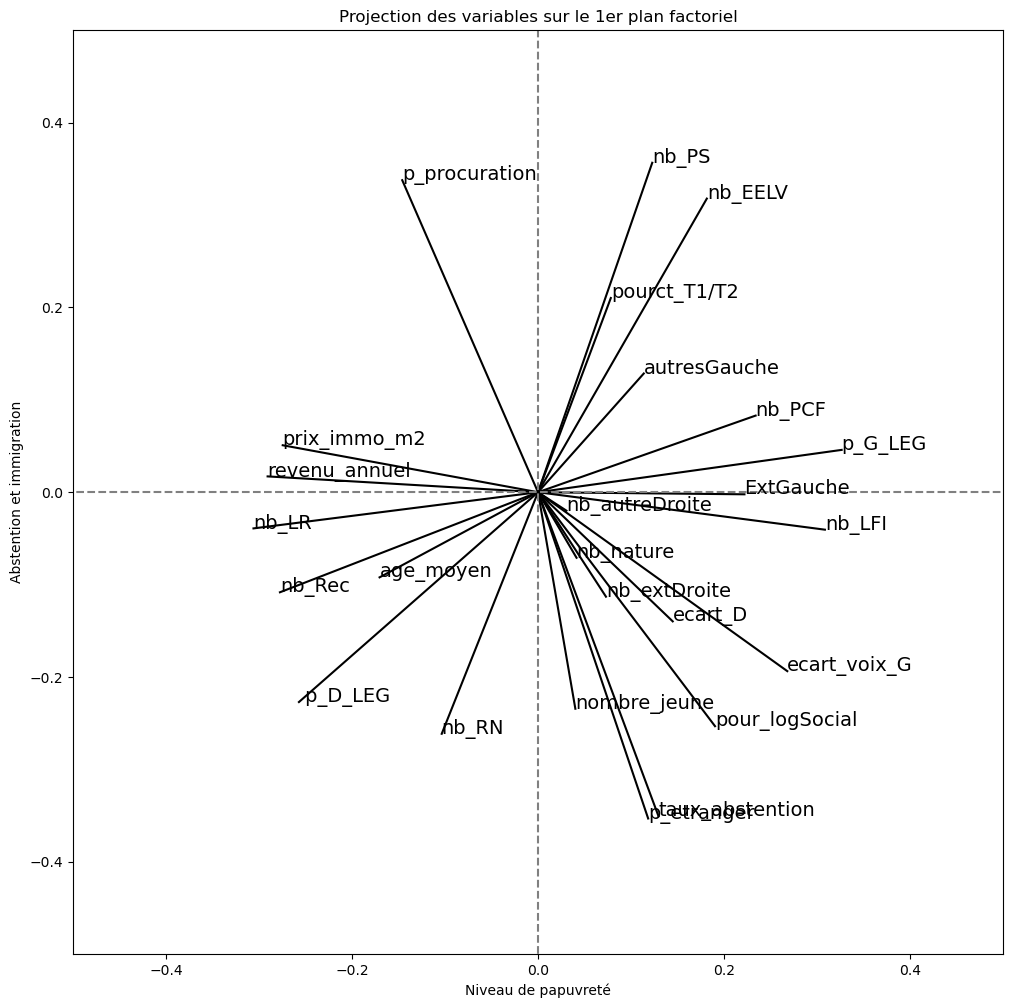

In [36]:
#Cercle des corrélations 

plt.figure(figsize = (12,12))


#Un cercle des corrélation plus simplifiés

for i, (x,y) in enumerate(zip(pcs_train[0,:], pcs_train[1,:])):
    
    plt.plot([0,x],[0,y],color='k') # Afficher un segment d'origine
    
    plt.text(x,y,abst_acp.columns[i],fontsize='14') #Affciher les noms
    
    
    
    
plt.plot([-1,1],[0,0], color = 'grey', ls='--')#Afficher une ligne horizontale
plt.plot([0,0],[-1,1], color = 'grey', ls='--')#Afficher une ligne verticale

plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)

plt.ylabel('Abstention et immigration')
plt.xlabel('Niveau de papuvreté')


plt.title('Projection des variables sur le 1er plan factoriel')

plt.savefig("PremierPlanFactoriel_ind.png")

In [52]:
#Une projection des individus sur les composantes principales

X_projected = pca_train.transform(X_scaled)


individu =pd.DataFrame(X_projected)
individu = individu.rename(columns = {0:'Niveau de pauvreté',1:'Niveau de participation'})


pol = politiques.reset_index()
pol = pol["id_bv"]


#Mettre les burau de vote comme identifiant
individu = pd.concat([individu, pol], axis = 1)
individu = individu.set_index(['id_bv'])



individu.to_csv('ind_acp.csv')

individu

,Niveau de pauvreté,Niveau de participation
id_bv,,
01_01,-2.713253,0.003022
01_02,-1.910188,1.431364
01_03,-0.942895,1.169815
01_04,0.356779,0.258803
01_05,-0.892899,1.570877
...,...,...
20_72,4.951529,-0.118599
20_73,4.238610,2.181521
20_74,4.438447,3.045154


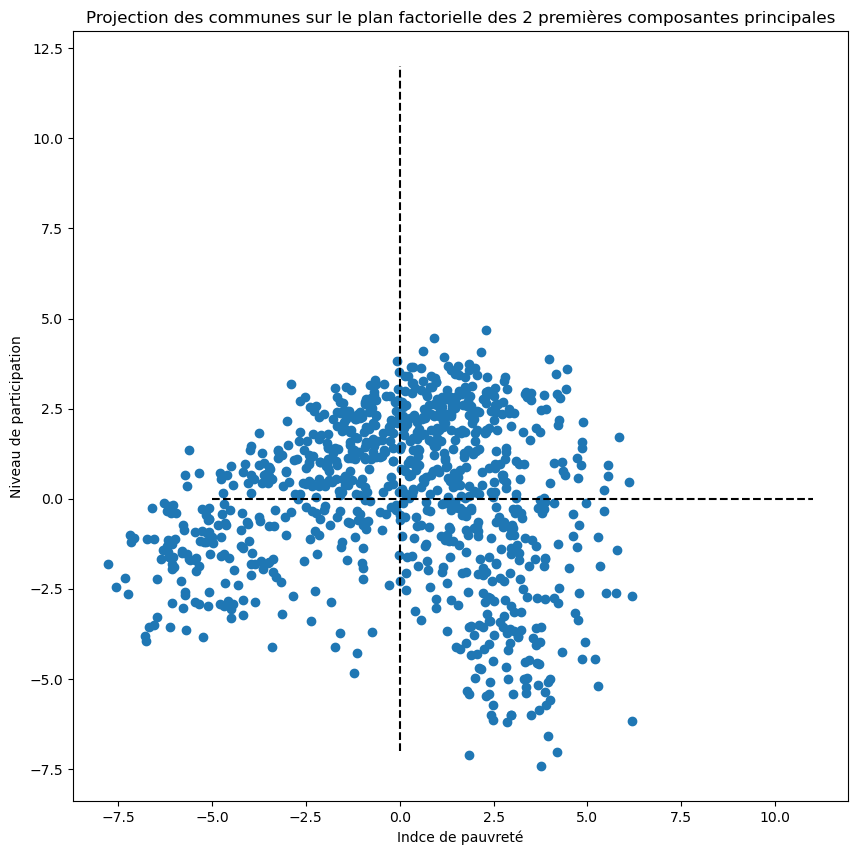

In [53]:
#Projection des bureaux de votes dans notre plan factoriel

plt.figure(figsize=(10,10))

plt.scatter(X_projected[:,0],X_projected[:,1])

    
plt.plot([-5,11],[0,0], color = 'black', ls='--')#Afficher une ligne horizontale
plt.plot([0,0],[-7,12], color = 'black', ls='--')#Afficher une ligne verticale    
    

plt.ylabel("Niveau de participation")
plt.xlabel('Indce de pauvreté')
    
plt.title("Projection des communes sur le plan factorielle des 2 premières composantes principales")    
plt.savefig("IndividusPlan.png") 

# 4 - Contructions du clusters avec le K-means

In [54]:
#Importation du module pour les clusters

#pour déterminer les clusters
from sklearn import cluster, metrics 

#module pour faire le K-Means
from sklearn.cluster import KMeans

### 4-1 Choix du nombre de Cluster

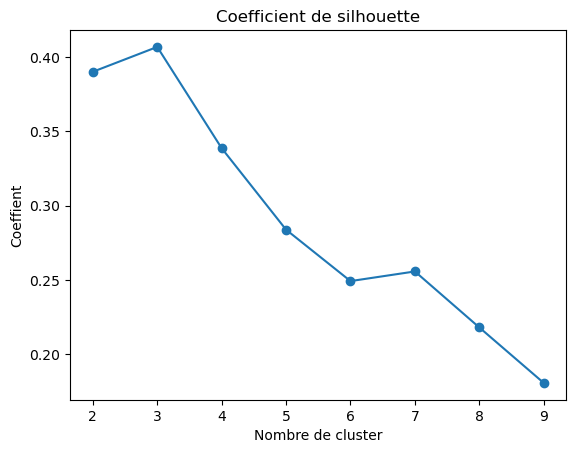

In [55]:
#Calcul du coefficient de silhouettes

silhouettes = []
for num_clusters in range(2,10):
    cls = cluster.KMeans(n_clusters = num_clusters,
                        n_init=1,
                        init='random')
    cls.fit(abst_acp)
    silh = metrics.silhouette_score(individu,cls.labels_)
    silhouettes.append(silh)
    
#Afficher graphiquement ce coefficient 
plt.plot(range(2,10),silhouettes,marker='o')
plt.title("Coefficient de silhouette")
plt.xlabel('Nombre de cluster')
plt.ylabel('Coeffient')
plt.savefig('coef_solhouette.png')
plt.show()

In [56]:
#liste de coefficient de silhouette

silhouettes

[0.39018845870629176,
 0.40694334681667793,
 0.3387008129316874,
 0.2837838972878745,
 0.24913425122254182,
 0.25563148967386373,
 0.2178889291378069,
 0.18051293737270854]

D'après le coefficient de silhouette , on décide de faire une partition en 3 Cluster

### 4-2 Projection de nos clusters 

In [57]:
#Choix du nombre de cluster 
km = KMeans(n_clusters = 3)
km.fit(individu)

#Récupération des cluster attribué à chaque individu
cluster = km.labels_
model = KMeans(n_clusters=3)
model.fit(individu)

#On peut comment sont classées les points selon les clusters
model.predict(individu)



array([0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1,

In [58]:
### mettre en DataFrame
cluster_df = pd.DataFrame(model.predict(individu))

#Renommage des colonnes
cluster_df = cluster_df.rename(columns = {0:'Cluster'})

cluster_df = cluster_df.reset_index(drop = True)


#Mettre les burau de vote comme identifiant
cluster_df = pd.concat([cluster_df, pol], axis = 1)
cluster_df = cluster_df.set_index(['id_bv'])




cluster_df.head(10)

,Cluster
id_bv,
01_01,0
01_02,1
01_03,1
01_04,1
01_05,1
01_06,1
01_07,0
01_08,0
01_09,0


In [59]:
#Mettre les cluster dans les données des individus progétés

individu_cluster = individu.merge(cluster_df,on="id_bv")

#Enregistrement en du jeux de données des cluster en CSV
individu_cluster.to_csv("cluster_BV.csv",sep=";")

individu_cluster.head(5)

,Niveau de pauvreté,Niveau de participation,Cluster
id_bv,,,
01_01,-2.713253,0.003022,0
01_02,-1.910188,1.431364,1
01_03,-0.942895,1.169815,1
01_04,0.356779,0.258803,1
01_05,-0.892899,1.570877,1


In [60]:
#Nombre d'occurence par cluster 

individu_cluster["Cluster"].value_counts()

Cluster
1    455
0    227
2    219
Name: count, dtype: int64

In [61]:
#Découper les données en cluster 

cluster0 = individu_cluster[individu_cluster['Cluster'] == 0]
cluster1 = individu_cluster[individu_cluster['Cluster'] == 1]
cluster2 = individu_cluster[individu_cluster['Cluster'] == 2]

In [62]:
cluster0

,Niveau de pauvreté,Niveau de participation,Cluster
id_bv,,,
01_01,-2.713253,0.003022,0
01_07,-2.408860,0.969676,0
01_08,-2.905887,-0.365066,0
01_09,-3.962507,0.156400,0
01_10,-3.878838,0.536896,0
...,...,...,...
17_63,-3.646324,-1.963002,0
17_64,-3.944633,-1.501453,0
17_65,-4.641656,-0.669902,0


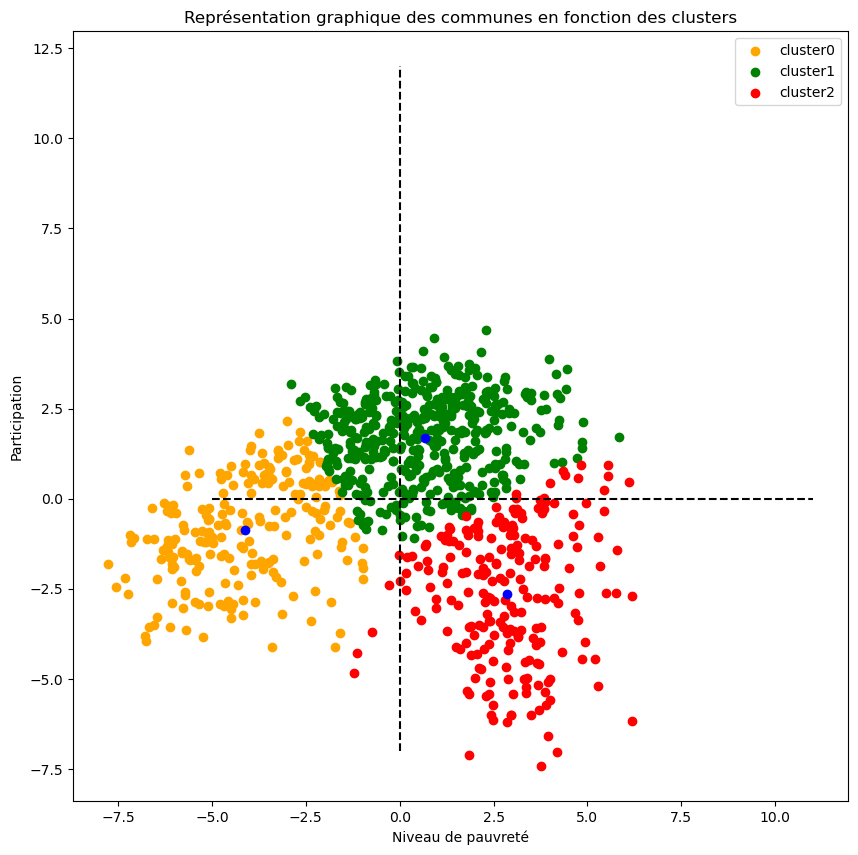

In [63]:
plt.figure(figsize=(10,10))

#Mettre les couleurs par cluster

plt.scatter(cluster0["Niveau de pauvreté"],cluster0['Niveau de participation'],c='orange',label ='cluster0')
plt.scatter(cluster1["Niveau de pauvreté"],cluster1['Niveau de participation'],c='green',label = 'cluster1')
plt.scatter(cluster2["Niveau de pauvreté"],cluster2['Niveau de participation'],c='red',label = 'cluster2')

plt.legend()


#On va placer les centroïdes 
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], c='b')

plt.plot([-5,11],[0,0], color = 'black', ls='--')#Afficher une ligne horizontale
plt.plot([0,0],[-7,12], color = 'black', ls='--')#Afficher une ligne verticale   

plt.title("Représentation graphique des communes en fonction des clusters")

plt.xlabel("Niveau de pauvreté")
plt.ylabel("Participation")


plt.savefig("Cluster_K-Means.png")

### 4-3 Statistiques de nos cluters 

In [64]:
#Nombre d'occurence par cluster 

pd.DataFrame(individu_cluster["Cluster"].value_counts())

,count
Cluster,
1,455
0,227
2,219


In [ ]:
# 